In [70]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def load_peak_stats_for_cell(stats_path, cell_name, usecols=None, chunksize=50000):
    """
    Load only rows for one cell from a large peak-stats CSV.

    Parameters
    ----------
    stats_path : str or Path
    cell_name : str
        Example: "cell_3"
    usecols : list or None
        Columns to load. If None, loads all columns.
    chunksize : int
        Number of rows per chunk.

    Returns
    -------
    pd.DataFrame
    """
    stats_path = Path(stats_path)

    if usecols is not None and "cell" not in usecols:
        usecols = ["cell"] + list(usecols)

    chunks = []
    for chunk in pd.read_csv(stats_path, usecols=usecols, chunksize=chunksize, low_memory=False):
        sub = chunk.loc[chunk["cell"] == cell_name]
        if not sub.empty:
            chunks.append(sub)

    if not chunks:
        return pd.DataFrame(columns=usecols if usecols is not None else None)

    return pd.concat(chunks, ignore_index=True)

def list_cells_in_peak_stats(stats_path, chunksize=50000):
    seen = set()
    for chunk in pd.read_csv(stats_path, usecols=["cell"], chunksize=chunksize):
        seen.update(chunk["cell"].dropna().unique())

    def natural_cell_key(name):
        m = re.match(r"cell_(\d+)$", str(name))
        if m:
            return (0, int(m.group(1)))
        return (1, str(name))

    return sorted(seen, key=natural_cell_key)




In [35]:
##path to dataframe 
stats_path = Path("/scratch/jma819/CaliAli_linearTrackData/m388_analysis/all_peak_stats_20260518_211705.csv")

#matching full Ca2+ traces for full length of traces 
csv_path = Path("/scratch/jma819/CaliAli_linearTrackData/m388_analysis/GCAMP_with_velocity.csv")
with csv_path.open("r") as f:
    n_rows = sum(1 for _ in f) - 1  # subtract header


In [37]:
#preview only a few rows 
preview_df = pd.read_csv(stats_path, nrows=10)
preview_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end
0,cell_1,0,83,0,236927,20.931425,236927,0,236927
1,cell_1,1,373,220,960,8.954209,740,210,970
2,cell_1,2,1990,1965,9018,20.931425,7053,1955,9028
3,cell_1,3,2066,2047,2248,8.133774,201,2037,2258
4,cell_1,4,2440,2246,3476,4.288657,1230,2236,3486
5,cell_1,5,3265,3073,3476,3.222699,403,3063,3486
6,cell_1,6,4019,3946,4118,3.429064,172,3936,4128
7,cell_1,7,4335,4116,5017,20.931425,901,4106,5027
8,cell_1,8,5949,5776,8829,12.843619,3053,5766,8839
9,cell_1,9,6563,6361,7027,12.771102,666,6351,7037


In [38]:
#list cells in recording
cells = list_cells_in_peak_stats(stats_path)
cells[:20]

['cell_1',
 'cell_3',
 'cell_4',
 'cell_5',
 'cell_6',
 'cell_7',
 'cell_8',
 'cell_9',
 'cell_10',
 'cell_11',
 'cell_12',
 'cell_15',
 'cell_16',
 'cell_17',
 'cell_18',
 'cell_19',
 'cell_20',
 'cell_21',
 'cell_22',
 'cell_23']

In [39]:
# load one cell 
cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name="cell_421")


In [40]:
cell_stats_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end
0,cell_421,0,443,422,727,3.526018,305,412,737
1,cell_421,1,807,780,1117,8.726634,337,770,1127
2,cell_421,2,3849,3822,3911,15.085277,89,3812,3921
3,cell_421,3,4426,4403,4504,3.581605,101,4393,4514
4,cell_421,4,5323,5252,14925,8.914641,9673,5242,14935
...,...,...,...,...,...,...,...,...,...
377,cell_421,377,232985,232942,233236,4.338217,294,232932,233246
378,cell_421,378,233575,233503,234550,4.156005,1047,233493,234560
379,cell_421,379,235328,235179,235404,6.727946,225,235169,235414
380,cell_421,380,236579,236568,236726,4.978162,158,236558,236736


In [41]:
cell_stats_df.onset_idx

0         422
1         780
2        3822
3        4403
4        5252
        ...  
377    232942
378    233503
379    235179
380    236568
381    236568
Name: onset_idx, Length: 382, dtype: int64

In [48]:
n_rows

236928

In [66]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
window_len = 20
onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")


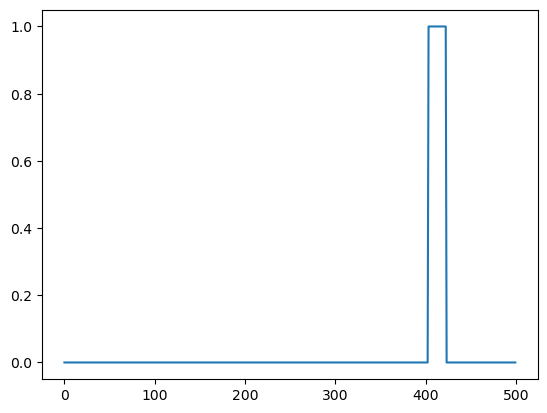

In [72]:
plt.plot(eventsPerSecond_convolve[0:500])

In [ ]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window for all cells 
cells = list_cells_in_peak_stats(stats_path)
events_per_second_dict = {}
for cell in cells:
    print(cell)
    cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name=cell)
    # calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
    window_len = 20
    onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
    eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")
    events_per_second_dict[cell] = eventsPerSecond_convolve

In [76]:
eventsPerSecond_df = pd.DataFrame(events_per_second_dict)

In [81]:
eventsPerSecond_df.mean(axis=0)

cell_1      0.032759
cell_3      0.038833
cell_4      0.043477
cell_5      0.029632
cell_6      0.052172
              ...   
cell_677    0.039593
cell_679    0.038243
cell_682    0.031151
cell_683    0.041201
cell_684    0.037483
Length: 601, dtype: float64

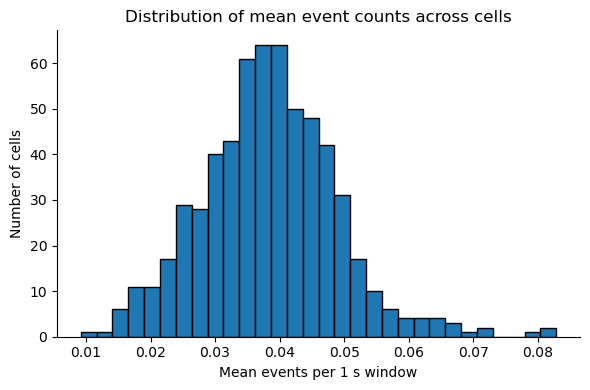

In [82]:
# histogram of firing rate across all cells
import matplotlib.pyplot as plt

mean_events_per_cell = eventsPerSecond_df.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mean_events_per_cell, bins=30, edgecolor="black")
ax.set_xlabel("Mean events per 1 s window")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of mean event counts across cells")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
